* Seeting up a virtual environment is needed, the codes are in the following:


conda create -n econml-py39 python=3.9
conda activate econml-py39
pip install numpy==1.23.5 scipy==1.10.1 pandas==1.5.3 scikit-learn==1.2.2 matplotlib==3.6.3 seaborn==0.12.2 xgboost==1.7.5 lightgbm==3.3.5 shap==0.43.0 econml==0.15.0

pip install ipykernel
python -m ipykernel install --user --name econml-py39 --display-name econml-py39


In [2]:
from econml.grf import CausalForest
import numpy as np
import scipy.special
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS
from docx import Document
from docx.shared import Inches
import scipy.stats as stats
from scipy.stats import pearsonr
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col


count    9892.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: derhedgl_binary, dtype: float64

In [3]:
df = pd.read_csv('cemlcbq2vszshspq.csv')
df['derhedgl_binary'] = df['derhedgl'].apply(lambda x: 0 if pd.isna(x) else 1) #dummy for derivative use
# Filtering data by total assets,total debt, market value. If there was any 0 value during the research period, the company(gvkey) is delated
to_exclude = df[(df['at'] == 0) | (df['dt'] == 0) | (df['mkvalt'] == 0 )|(df['ni'] == 0)|(df['capx']==0)
                  ].gvkey.unique()
filtered_data = df[~df['gvkey'].isin(to_exclude)]
filtered_data = filtered_data.dropna(subset= ['dt','mkvalt','capx','at','ni','lt'])
filtered_data.isna().sum()
filtered_len = len(filtered_data)
filtered_data['derhedgl_binary'].describe()
filtered_data['ln_mkvalt'] = np.log(filtered_data['mkvalt'])

filtered_data['ln_at'] = np.log(filtered_data['at'])
filtered_data['ln_dt'] = np.log(filtered_data['dt'])
#filtered_data['ln_cidergl'] = np.log(filtered_data['cidergl'])
filtered_data['ln_mkvalt'] = np.log(filtered_data['mkvalt'])
filtered_data['ln_lt'] = np.log(filtered_data['lt'])
filtered_data['current_ratio'] = filtered_data['ln_at'] - filtered_data['ln_lt']
filtered_data['debt_to_equity'] = filtered_data['ln_dt'] / (filtered_data['ln_at'] - filtered_data['ln_dt'])                                                                        
filtered_data['tobins_q'] = (filtered_data['mkvalt']) / filtered_data['at']
filtered_data['ROA'] = filtered_data['ni']/filtered_data['at']
filtered_data['leverage'] = filtered_data['dt']/filtered_data['at']
filtered_data['sic_group'] = filtered_data['sic'].astype(str).str[:1]
sic_group_dummies = pd.get_dummies(filtered_data['sic_group'], prefix='sic_group')
filtered_data = pd.concat([filtered_data, sic_group_dummies], axis=1)
print(len(filtered_data))
filtered_data.isna().sum()

filtered_data.to_csv('filtered_data.csv', index=False)





C:\Users\85832\AppData\Local\Temp\ipykernel_32280\2129057160.py:1: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('cemlcbq2vszshspq.csv')


36379


In [4]:
print("derhedgl_binary:") 
print(filtered_data['derhedgl_binary'].describe()) 

derhedgl_binary:
count    36379.000000
mean         0.257016
std          0.436995
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: derhedgl_binary, dtype: float64


In [18]:

def calculate_basic_statistics(df, variables):
    """
    calculating basic stats
    """

    financial_vars = ['at', 'dt', 'mkvalt', 'ni', 'capx', 'lt', 'tobins_q', 'derhedgl', 'ROA', 'tobins_q] 
    desc_stats = df[financial_vars].describe().round(2)
    
    additional_stats = pd.DataFrame({
        'Skewness': df[financial_vars].skew(),
        'Kurtosis': df[financial_vars].kurtosis(),
        'Median': df[financial_vars].median(),
        'CV': df[financial_vars].std() / df[financial_vars].mean(),
        'JB_Stattistic': df[financial_vars].apply(lambda x: stats.jarque_bera(x)[0]),
        'JB_p': df[financial_vars].apply(lambda x: stats.jarque_bera(x)[1])
    }).round(3)
    
    # append
    full_stats = pd.concat([desc_stats.T, additional_stats], axis=1)
    
    return full_stats

def create_detailed_statistics_table(df, variable_names):
    var_mapping = {
        'at': 'Total Assets',
        'dt': 'Total Debts', 
        'mkvalt': 'Market Value',
        'ni': 'Net Income',
        'capx': 'Capital Expenditure',
        'lt': 'Total loan',
        'tobins_q': 'tobins_q',
        'derhedgl': 'Derivative Hedging Gain/Loss',
        'ROA': 'ROA'
    }
    
    stats_table = calculate_basic_statistics(df, variable_names)
    

    stats_table.index = stats_table.index.map(var_mapping)
    
    return stats_table


basic_stats = calculate_basic_statistics(filtered_data, 
                                        ['at', 'dt', 'mkvalt', 'ni', 'capx', 'lt', 'tobins_q', 'derhedgl', 'ROA'])


detailed_stats = create_detailed_statistics_table(filtered_data, 
                                                 ['at', 'dt', 'mkvalt', 'ni', 'capx', 'lt', 'tobins_q', 'derhedgl', 'ROA'])

print(detailed_stats)

basic_stats.to_excel('basic_statistics.xlsx', float_format='%.4f')

def pearson_correlation_matrix(data, variables=None):
    """
   Multi variables corr matrix
    """
    if variables is None:
        variables = data.select_dtypes(include=[np.number]).columns.tolist()
    
    corr_matrix = data[variables].corr(method='pearson')
    return corr_matrix

variables = ['at', 'dt', 'mkvalt', 'ni', 'capx', 'lt','tobins_q', 'derhedgl','ROA']
corr_matrix = pearson_correlation_matrix(filtered_data, variables)
print("Pearson Correlation Matrix:")
print(corr_matrix.round(2))


                                count      mean       std       min     25%  \
Total Assets                  36379.0  10770.60  62838.49      0.00  257.73   
Total Debts                   36379.0   2737.89  10978.12      0.00   35.91   
Market Value                  36379.0   8668.75  40652.55      0.00  167.71   
Net Income                    36379.0    356.46   1908.01 -23119.00  -11.66   
Capital Expenditure           36379.0    347.49   1501.37  -3258.00    5.48   
Total loan                    36379.0   7922.01  56236.55      0.17  120.38   
tobins_q                      36379.0      2.48    155.09      0.00    0.42   
Derivative Hedging Gain/Loss   9350.0      0.42     99.28  -2183.00   -2.19   
ROA                           36379.0     -0.18     17.20  -3267.67   -0.04   

                                  50%      75%         max  Skewness  \
Total Assets                  1268.05  4979.76  2004992.00    17.788   
Total Debts                    349.54  1656.83   426314.00    14.

In [21]:
#poolols 

y_var = 'tobins_q'  
x_vars =  ['ROA', 'leverage', 'current_ratio', 'debt_to_equity','derhedgl_binary']
reg_data = filtered_data[[y_var] + x_vars].dropna()
y = reg_data[y_var]
X = reg_data[x_vars]
X = sm.add_constant(X)  # constant
POLS_tobinsq = sm.OLS(y, X).fit()


y_var = 'ln_mkvalt'  
reg_data = filtered_data[[y_var] + x_vars].dropna()
y = reg_data[y_var]
X = reg_data[x_vars]
X = sm.add_constant(X)  # constant
POLS_mkvalt = sm.OLS(y, X).fit()

print("Summary:")
print(POLS_tobinsq.summary())
print(POLS_mkvalt.summary())
results_table = summary_col([POLS_tobinsq, POLS_mkvalt],
                           model_names=['Tobins Q', 'Market Value'],
                           stars=True,
                           regressor_order=['const'] + x_vars,
                           info_dict={
                               'N': lambda x: f"{x.nobs:.0f}",
                               'R2': lambda x: f"{x.rsquared:.3f}",
                               'Adj R2': lambda x: f"{x.rsquared_adj:.3f}"
                           })

print(results_table)

Summary:
                            OLS Regression Results                            
Dep. Variable:               tobins_q   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     58.68
Date:                Thu, 13 Nov 2025   Prob (F-statistic):           4.71e-61
Time:                        13:46:16   Log-Likelihood:            -2.3497e+05
No. Observations:               36379   AIC:                         4.700e+05
Df Residuals:                   36373   BIC:                         4.700e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               8.5759      1

In [56]:
filtered_data = filtered_data.set_index(['gvkey','fyear']) #set index for panel regression
filtered_data.head()





,,costat,curcd,datafmt,indfmt,consol,tic,conm,cusip,exchg,fic,...,sic_group,sic_group_1,sic_group_2,sic_group_3,sic_group_4,sic_group_5,sic_group_6,sic_group_7,sic_group_8,sic_group_9
gvkey,fyear,,,,,,,,,,,,,,,,,,,,,
1004,2010,A,USD,STD,INDL,C,AIR,AAR CORP,000361105,11.0,USA,...,5,0,0,0,0,1,0,0,0,0
1013,2010,I,USD,STD,INDL,C,ADCT.1,ADC TELECOMMUNICATIONS INC,000886309,14.0,USA,...,3,0,0,1,0,0,0,0,0,0
1019,2010,I,USD,STD,INDL,C,AFAP,AFA PROTECTIVE SYSTEMS INC,001038108,19.0,USA,...,7,0,0,0,0,0,0,1,0,0
1045,2010,A,USD,STD,INDL,C,AAL,AMERICAN AIRLINES GROUP INC,02376R102,14.0,USA,...,4,0,0,0,1,0,0,0,0,0
1076,2010,A,USD,STD,INDL,C,PRG,PROG HOLDINGS INC,74319R101,11.0,USA,...,6,0,0,0,0,0,1,0,0,0


In [18]:
#filtering data with hdgl_binary=1 for further test
#if thereis na still using the following code to clean again
#filtered_data = filtered_data[(filtered_data['capx'] != 0) & (filtered_data['capx'].notna()) &
#(filtered_data['derhedgl'].notna()) &(filtered_data['ni'].notna())]

der_set = filtered_data[filtered_data['derhedgl_binary'] == 1]
der_set['hdgl_at'] = der_set['derhedgl']/der_set['at']
der_set['hdgl_capx'] = der_set['derhedgl']/der_set['capx']
der_set['hdgl_ni'] = der_set['derhedgl']/der_set['ni']
print(der_set.describe())

non_der_set = filtered_data[filtered_data['derhedgl_binary'] == 0]
print(der_set.describe())

der_set.to_csv('der_set.csv', index=False)

C:\Users\85832\AppData\Local\Temp\ipykernel_32280\3420436775.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  der_set['hdgl_at'] = der_set['derhedgl']/der_set['at']
C:\Users\85832\AppData\Local\Temp\ipykernel_32280\3420436775.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  der_set['hdgl_capx'] = der_set['derhedgl']/der_set['capx']
C:\Users\85832\AppData\Local\Temp\ipykernel_32280\3420436775.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .lo

             fyear          gvkey        exchg           gind          sic  \
count  9350.000000    9350.000000  9350.000000    9347.000000  9350.000000   
mean   2017.953583   74454.624171    13.806952  277586.019044  4024.810053   
std       3.259941   75606.414846     3.178683  135090.820760  2056.987668   
min    2013.000000    1078.000000     1.000000  101010.000000   100.000000   
25%    2015.000000   14312.000000    11.000000  151040.000000  2833.000000   
50%    2018.000000   35222.000000    14.000000  252030.000000  3670.000000   
75%    2021.000000  154135.000000    14.000000  352020.000000  5065.000000   
max    2023.000000  351491.000000    19.000000  602010.000000  9997.000000   

           curuscn    aocidergl             at             lt      cidergl  \
count  1499.000000  8940.000000    9350.000000    9350.000000  9289.000000   
mean      0.791308    -4.177113   10872.217683    7081.873164    -0.052994   
std       0.068317    87.625032   28717.480859   19319.966731  

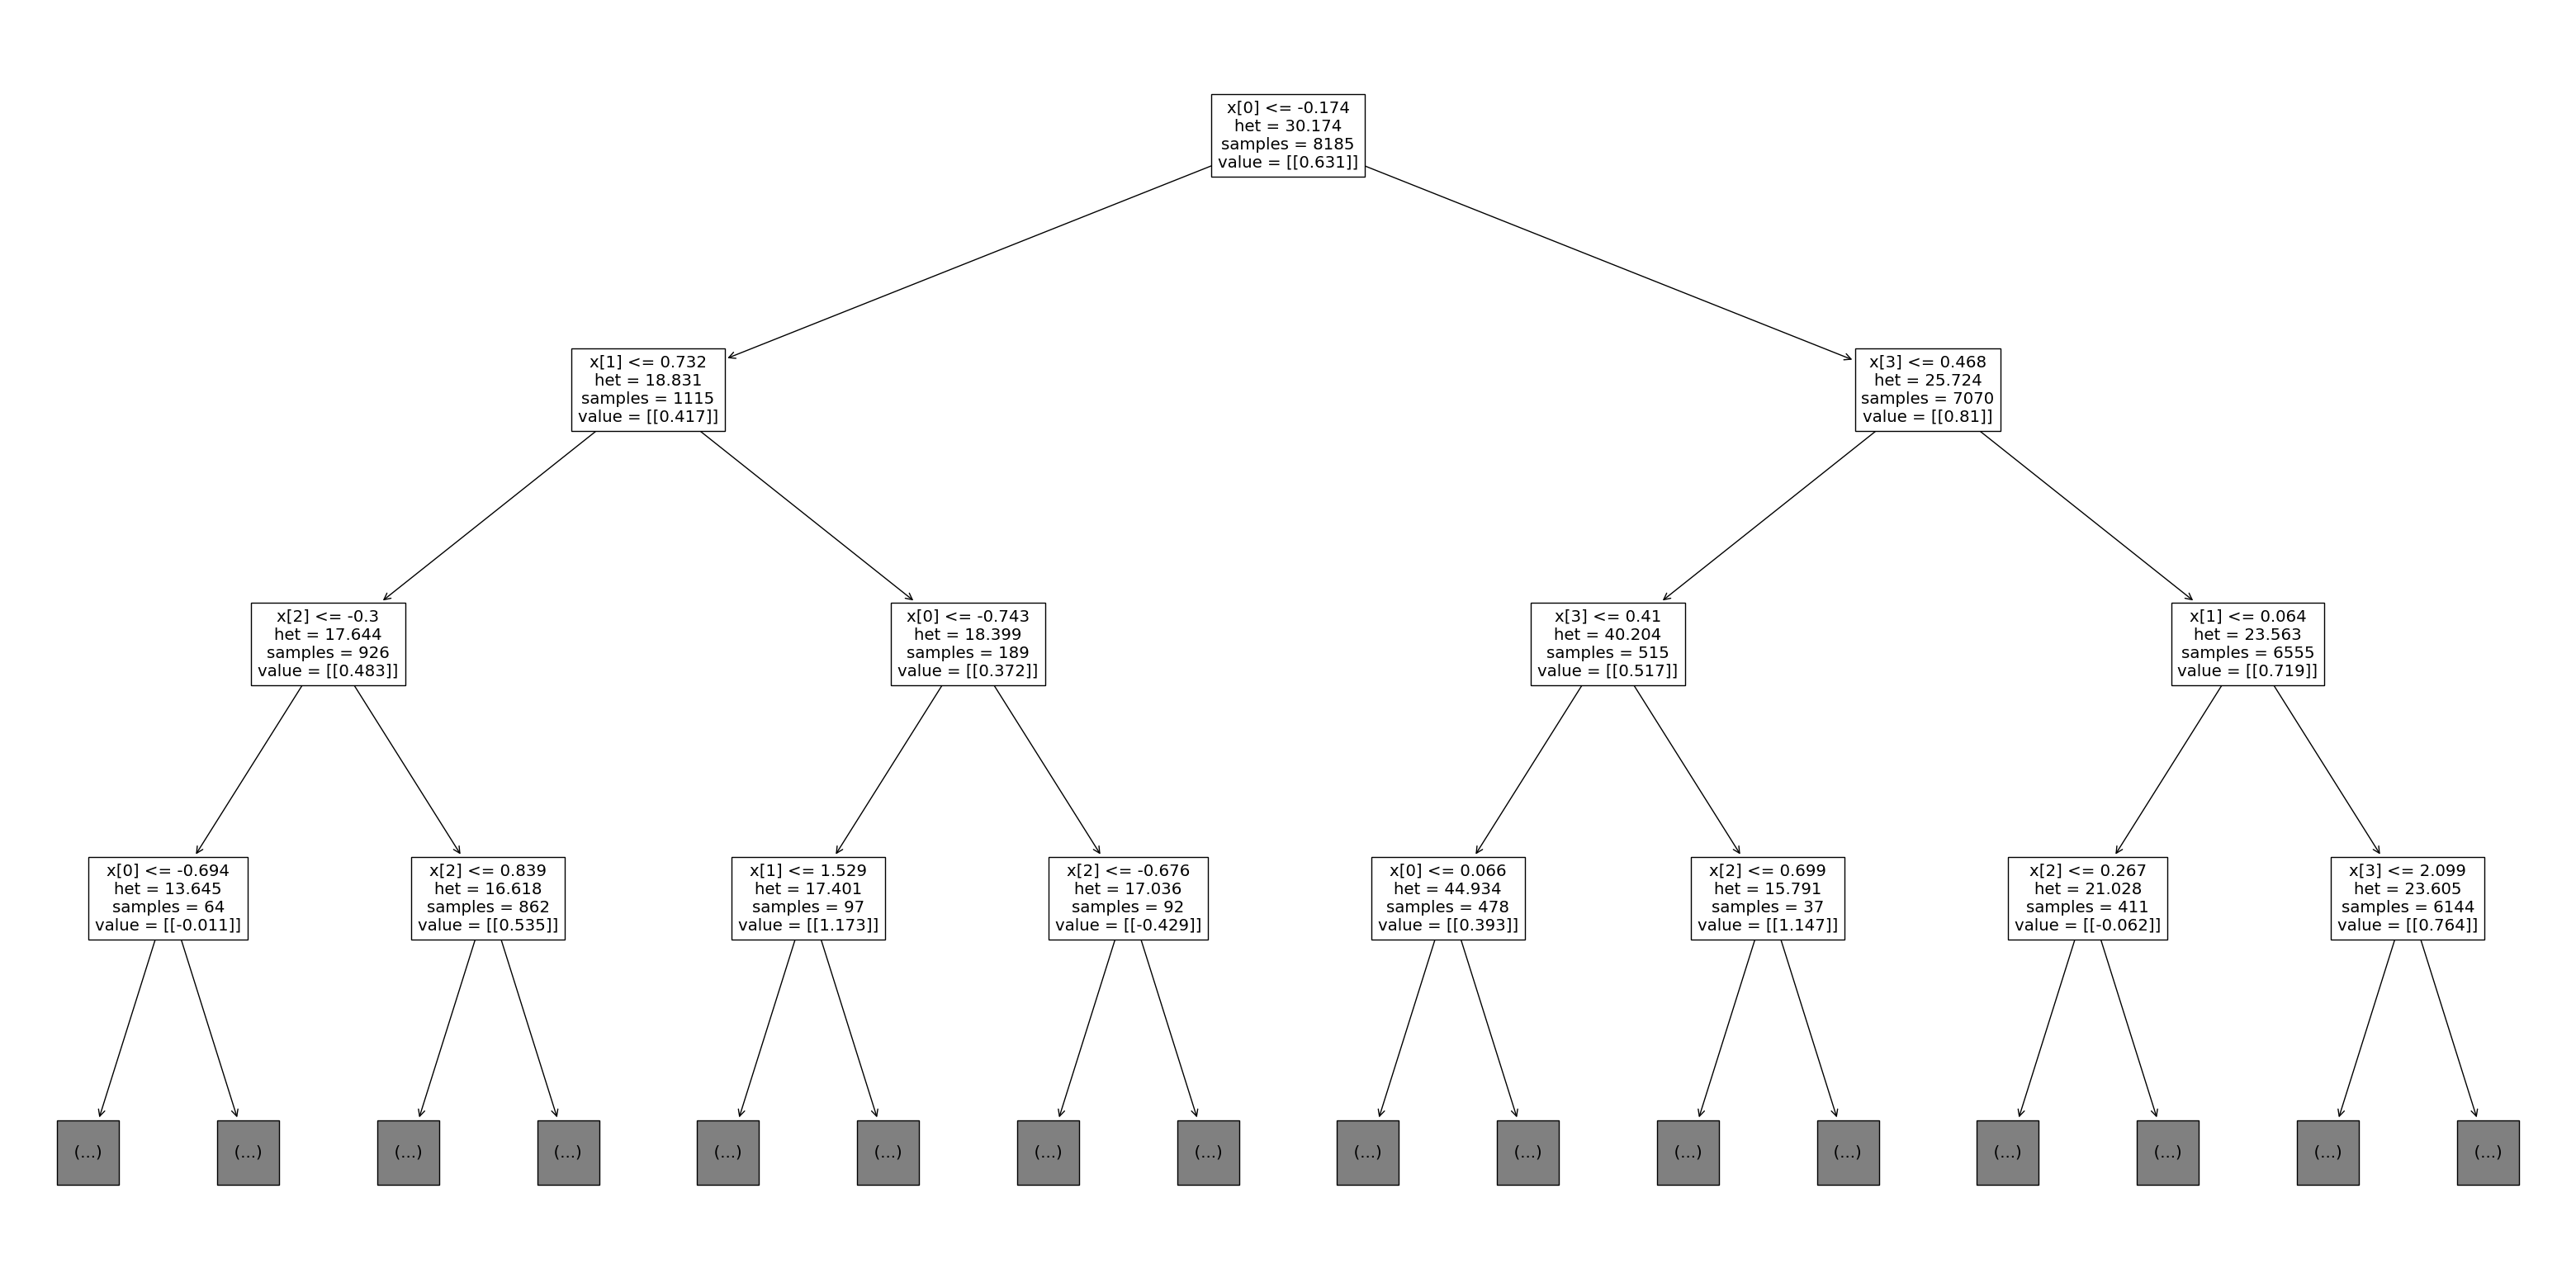

ATE: 0.3353
SE: 0.0019
95%confidentual: [0.3316, 0.3390]


In [5]:
X = filtered_data[['ROA', 'leverage', 'current_ratio', 'debt_to_equity']].values
T = filtered_data['derhedgl_binary'].values
y = filtered_data['ln_mkvalt'].values.reshape(-1, 1)


# setting CausalForest
est = CausalForest(criterion='het', n_estimators=2000, min_samples_leaf=5, max_depth=None,
                   min_var_fraction_leaf=None, min_var_leaf_on_val=True,
                    max_samples=0.45, min_balancedness_tol=.45,
                   warm_start=False, inference=True, fit_intercept=True, subforest_size=4,
                   honest=True, verbose=0, n_jobs=-1, random_state=1235)


est.fit(X, T, y)

plt.figure(figsize=(40, 20))
plot_tree(est[0], impurity=True,  max_depth=3)
plt.show()

individual_effects = est.predict(X)

ate = np.mean(individual_effects)
ate_se = np.std(individual_effects) / np.sqrt(len(individual_effects))
print(f"ATE: {ate:.4f}")
print(f"SE: {ate_se:.4f}")
print(f"95%confidentual: [{ate - 1.96*ate_se:.4f}, {ate + 1.96*ate_se:.4f}]")

CATE from ATE: 0.1707


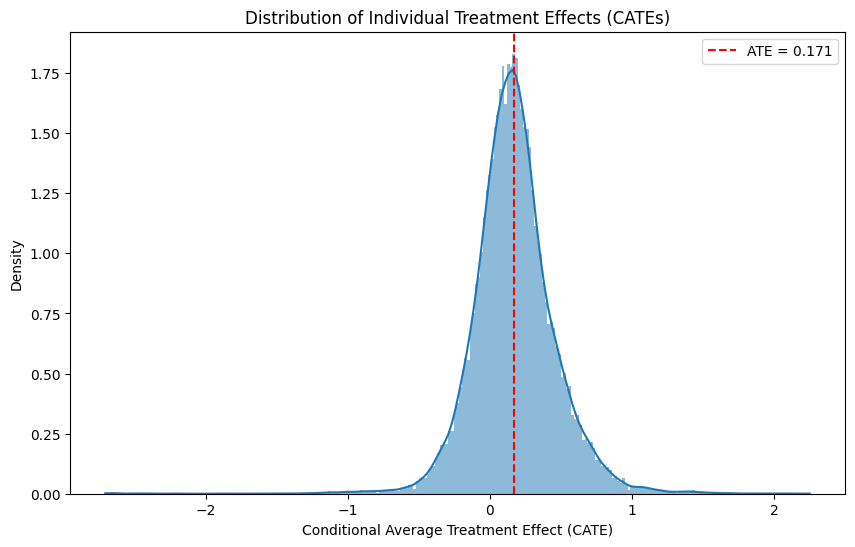

In [9]:
import seaborn as sns
cates = est.predict(X)
ate_value = np.mean(cates)
print (f"CATE from ATE: {ate_value:.4f}")
plt.figure(figsize=(10, 6))
sns.histplot(cates, kde=True, stat="density", linewidth=0)
plt.axvline(ate_value, color='red', linestyle='--', label=f'ATE = {ate_value:.3f}')
plt.xlabel('Conditional Average Treatment Effect (CATE)')
plt.ylabel('Density')
plt.title('Distribution of Individual Treatment Effects (CATEs)')
plt.legend()
plt.show()

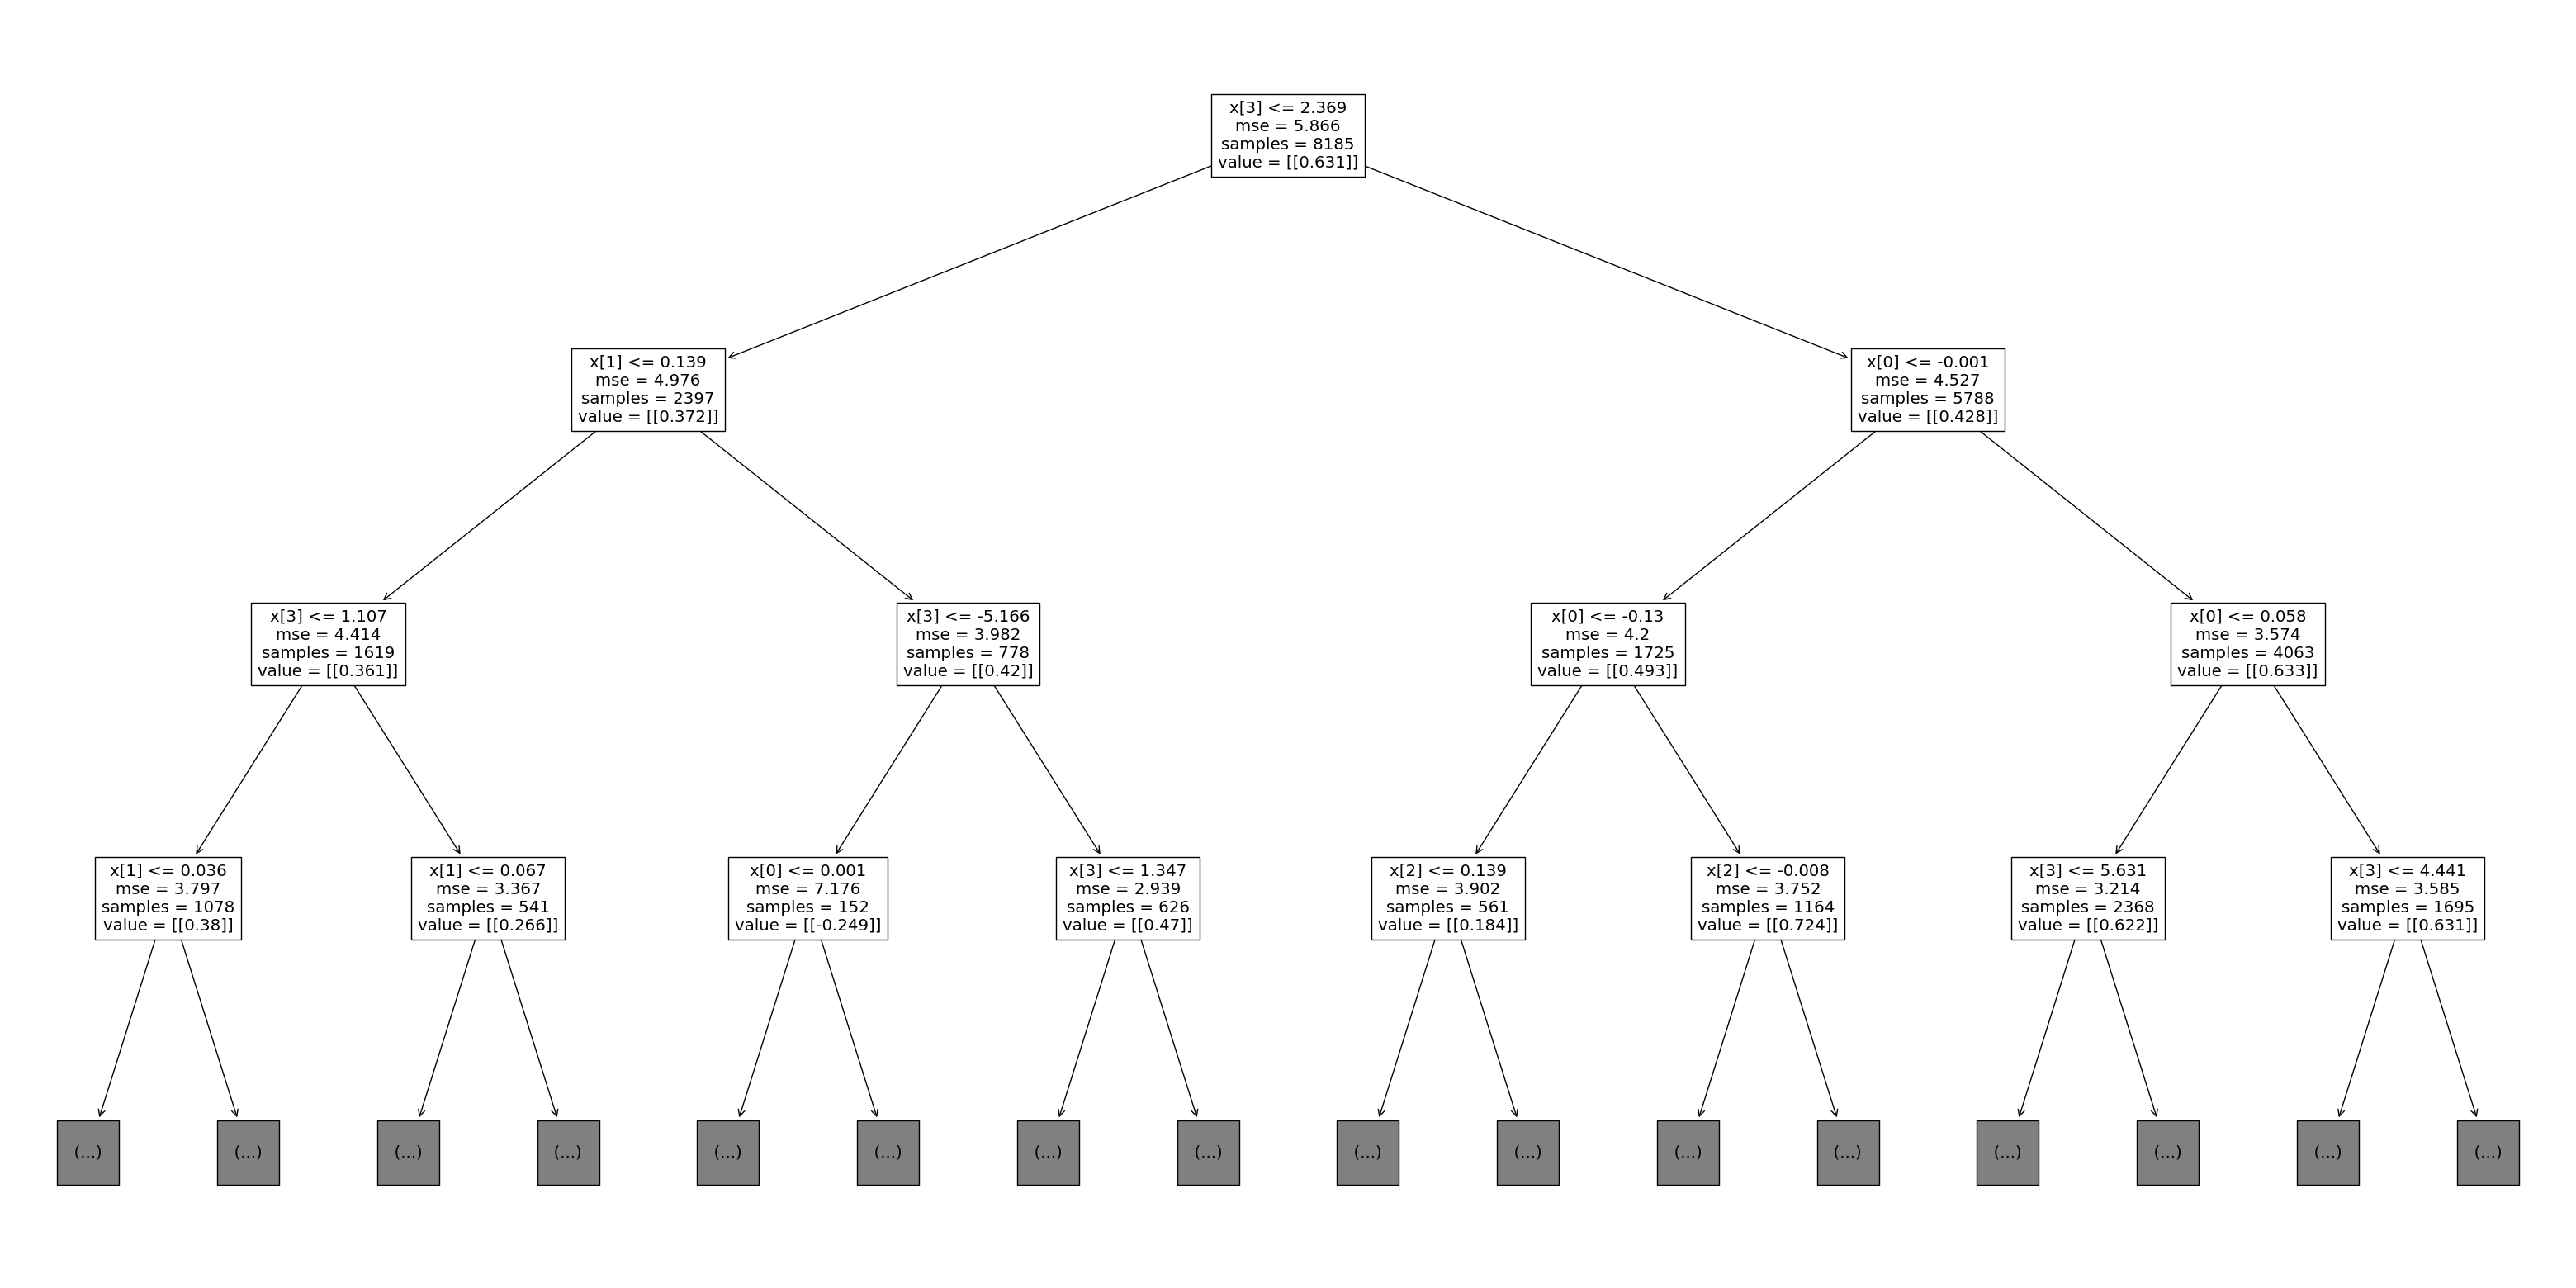

ATE: 0.1707
SE: 0.0015
95%confidentual: [0.1677, 0.1737]


In [6]:
X = filtered_data[['ROA', 'leverage', 'current_ratio', 'debt_to_equity']].values
T = filtered_data['derhedgl_binary'].values
y = filtered_data['ln_mkvalt'].values.reshape(-1, 1)


# setting CausalForest
est = CausalForest(criterion='mse', n_estimators=2000, min_samples_leaf=5, max_depth=None,
                   min_var_fraction_leaf=None, min_var_leaf_on_val=True,
                    max_samples=0.45, min_balancedness_tol=.45,
                   warm_start=False, inference=True, fit_intercept=True, subforest_size=4,
                   honest=True, verbose=0, n_jobs=-1, random_state=1235)


est.fit(X, T, y)

plt.figure(figsize=(40, 20))
plot_tree(est[0], impurity=True,  max_depth=3)
plt.show()

individual_effects = est.predict(X)
ate = np.mean(individual_effects)
ate_se = np.std(individual_effects) / np.sqrt(len(individual_effects))
print(f"ATE: {ate:.4f}")
print(f"SE: {ate_se:.4f}")
print(f"95%confidentual: [{ate - 1.96*ate_se:.4f}, {ate + 1.96*ate_se:.4f}]")